<a href="https://colab.research.google.com/github/LanqingDu/UnstructuredDataAnalytics/blob/main/Assignment4.ipynb" target="_blank">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# **Sentiment Analysis**



> **Instructor:** Dr. Lanqing Du  
> **Acknowledgement:** This notebook referenced to R user guide content, Machine Learning resoures, and the content created by Prof. Timothy E. Carone.  
> **Objective:** Introduction to Sentiment Analysis using R.  
> **Instructions:** You can preview the **Table of Contents** from the side bar.

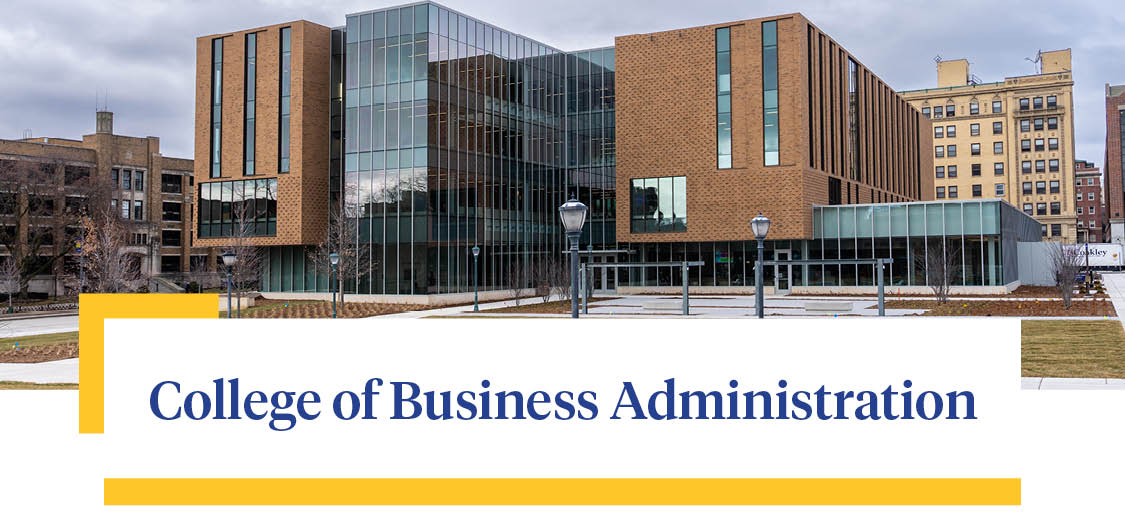
---

### 1. Load the library

In [2]:
# ========================================================
# Step 1: Install required packages
# ========================================================

# ~5 min
# Core data manipulation and visualization
install.packages("tidyverse")

# Text mining
install.packages("tidytext")
install.packages("wordcloud")

# Additional analysis
install.packages("igraph")      # If teaching text/network analysis
install.packages("cowplot")     # Combine, align, and arrange multiple ggplot2 plots


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘SnowballC’, ‘janeaustenr’, ‘tokenizers’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [3]:
# ========================================================
# Step 2: Load libraries
# ========================================================

library(tidyverse)
library(tidytext)
library(wordcloud)
library(cowplot)

Loading required package: RColorBrewer


Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp




### 2. Sentiment Lexicon


#### AFINN Lexicon


In [4]:
# ========================================================
# Step 3: Get the AFINN lexicon
# ========================================================

download.file("https://raw.githubusercontent.com/fnielsen/afinn/master/afinn/data/AFINN-111.txt",
              destfile = "AFINN-111.txt")

# read.delim(
#   file,                  # File name or file path
#   header = TRUE,         # TRUE if the first row contains column names
#   sep = "\t",            # Character used to separate columns; default is tab
#   quote = "\"",          # Character used to identify quoted text
#   dec = ".",             # Character used as the decimal point
#   fill = TRUE,           # Fill rows with missing values if row lengths differ
#   comment.char = "",     # Character used to identify comments
#   stringsAsFactors = FALSE # Whether text columns should be converted to factors
#   col.names = c()        # Specify col.names = c(...) when you want to assign your own names
# )

afinn <- read.delim("AFINN-111.txt",
                    header = FALSE,
                    stringsAsFactors = FALSE,
                    col.names = c("word", "value"))
head(afinn)

,word,value
,<chr>,<int>
1,abandon,-2
2,abandoned,-2
3,abandons,-2
4,abducted,-2
5,abduction,-2
6,abductions,-2


#### Bing Lexicon

In [5]:
# ========================================================
# Step 4: Get the Bing lexicon
# ========================================================

bing <- get_sentiments("bing")
head(bing)

bing %>%
  count(sentiment)

word,sentiment
<chr>,<chr>
2-faces,negative
abnormal,negative
abolish,negative
abominable,negative
abominably,negative
abominate,negative


sentiment,n
<chr>,<int>
negative,4781
positive,2005


#### NRC Lexicon


In [6]:
# ========================================================
# Step 5: Get the NRC lexicon
# ========================================================

# Download the NRC Emotion Lexicon
download.file("http://saifmohammad.com/WebDocs/Lexicons/NRC-Emotion-Lexicon.zip",
              destfile = "NRC-Emotion-Lexicon.zip")

# Unzip the downloaded file
unzip("NRC-Emotion-Lexicon.zip", exdir = "/content/nrc_lexicon")

# Verify the extracted files
list.files("nrc_lexicon")

# Specify the correct lexicon file path (adjust file name if different)
nrc_file <- "/content/nrc_lexicon/NRC-Emotion-Lexicon/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"

# Load the NRC lexicon into R
nrc <- read_delim(nrc_file, delim = "\t", col_names = c("word", "sentiment", "value"))

# Keep only word–sentiment pairs with a true association (value = 1)
# and remove the value column to create a clean lexicon for analysis
nrc <- nrc %>%
       filter(value == 1) %>%
       dplyr::select(-value)

# Preview the first few rows
head(nrc)

nrc %>%
  filter(sentiment %in% c("positive", "negative")) %>%
  count(sentiment)

[1] "__MACOSX"            "NRC-Emotion-Lexicon"

Rows: 141540 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (2): word, sentiment
dbl (1): value

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


word,sentiment
<chr>,<chr>
abacus,trust
abandon,fear
abandon,negative
abandon,sadness
abandoned,anger
abandoned,fear


sentiment,n
<chr>,<int>
negative,3316
positive,2308


### Sentiment Analysis with Jane Austen's Novels


#### TODO 1: Tokenize Jane Austen books


In [ ]:
# ========================================================
# Step 6: Download and include the library and data
# ========================================================

install.packages("janeaustenr")
library(janeaustenr)


# Note: R does not require indentation or enforce strict formatting rules.
# The following code is structured to clearly illustrate how operations are connected using the pipe operator for better readability and understanding. You do not need to follow this specific formatting style.


#################### TODO BELOW ####################

# 1. tokenization: use 'word' as the output column
# serve for later `inner_join()` and  `anti_joi()`

tidy_books <- austen_books()                                %>%
              group_by(book)                                %>%
              mutate(linenumber = row_number(),
                     chapter = cumsum(
                                     str_detect(text,
                                     regex("^chapter [\\divxlc]",
                                     ignore_case = TRUE)))) %>%
              ungroup()                                     %>%
              unnest_tokens(<...>, <...>)


#################### TODO ABOVE ####################


# Use word as the output column name in unnest_tokens().


# it is equivalent of the below with 2-steps
#
# tidy_books <- austen_books()                                %>%
#               group_by(book)                                %>%
#               mutate(linenumber = row_number(),
#                      chapter = cumsum(
#                                      str_detect(text,
#                                      regex("^chapter [\\divxlc]",
#                                      ignore_case = TRUE)))) %>%
#               ungroup()
#
#
# tidy_books <- unnest_tokens(<...>, <...>)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [8]:
# ========================================================
# Step 7: After tokenization examination
# ========================================================

colnames(tidy_books)
head(tidy_books)

[1] "book"       "linenumber" "chapter"    "word"

book,linenumber,chapter,word
<fct>,<int>,<int>,<chr>
Sense & Sensibility,1,0,sense
Sense & Sensibility,1,0,and
Sense & Sensibility,1,0,sensibility
Sense & Sensibility,3,0,by
Sense & Sensibility,3,0,jane
Sense & Sensibility,3,0,austen




- Now that the text is in a tidy format with one word per row, we are ready to do the sentiment analysis.

   - First, let’s use the NRC lexicon and `filter()` for the joy words.
   - Next, let’s `filter()` the data frame with the text from the books for the words from Emma and then use `inner_join()` to perform the sentiment analysis.
   - What are the most common joy words in Emma? Let’s use `count()` from dplyr.

#### TODO 2: Sentiment analysis with NRC

  - Sentiment analysis in **tidy text format** can be performed using an inner join between the text data and a sentiment lexicon—similar to how stop words are removed using an antijoin.

In [ ]:
# ========================================================
# Step 7: Reference the NRC sentiment lexicon
# ========================================================



#################### TODO BELOW ####################

# 1. we use the "joy" sentiment from NRC lexicon
#
nrc_joy <- nrc %>%
          filter(<...> == <...>)
#
#
# 2. we innerjoin with the joy sentiment lexicon
# 3. then we count the frequency
#
tidy_books %>%
          filter(book == "Emma") %>%
          inner_join(<...>) %>%
          count(<...>, sort = TRUE)
#
#
#################### TODO ABOVE ####################

#### TODO 3: Sentiment analysis with BING

In [ ]:
# ========================================================
# Step 8: Reference the bing sentiment lexicon
# ========================================================


#################### TODO BELOW ####################

# 1. Start with the tidy_books dataset.
# 2. Match the words in the books with the Bing sentiment lexicon.
# 3. Divide each book into groups of 80 lines.
# 4. Count how many positive and negative words occur in each group.
# 5. Put the positive and negative counts into separate columns.
# 6. Calculate a sentiment score:
#
#       sentiment = positive words - negative words
#
# A positive score means there are more positive words than negative
# words in that section.
#
# A negative score means there are more negative words than positive
# words in that section.

jane_austen_sentiment <- tidy_books %>%
                         inner_join(<...>) %>%
                         count(book, index = linenumber %/% 80, sentiment) %>%
                         pivot_wider(names_from = sentiment, values_from = n,  values_fill = 0) %>%
                         mutate(sentiment = <...> - <...>)

#################### TODO ABOVE ####################

Joining with `by = join_by(word)`
Warning message in inner_join(., bing):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 435434 of `x` matches multiple rows in `y`.
ℹ Row 5051 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


### Sentiment Visualizations (Optional)

In [21]:
# ========================================================
# Step 1: Pride & Prejudice Book
# ========================================================

pride_prejudice <- tidy_books %>%
                   filter(book == "Pride & Prejudice")

pride_prejudice

book,linenumber,chapter,word
<fct>,<int>,<int>,<chr>
Pride & Prejudice,1,0,pride
Pride & Prejudice,1,0,and
Pride & Prejudice,1,0,prejudice
Pride & Prejudice,3,0,by
Pride & Prejudice,3,0,jane
Pride & Prejudice,3,0,austen
Pride & Prejudice,7,1,chapter
Pride & Prejudice,7,1,1
Pride & Prejudice,10,1,it


In [22]:
# ========================================================
# Step 2: Referencing different sentiment lexicon
# ========================================================

book_afinn <- pride_prejudice %>%
              inner_join(afinn) %>%
              group_by(index = linenumber %/% 80) %>%
              summarise(sentiment = sum(value)) %>%
              mutate(method = "AFINN")


book_bing_and_nrc <- bind_rows(pride_prejudice %>%
                                inner_join(get_sentiments("bing")) %>%
                                mutate(method = "Bing"),

                               pride_prejudice %>%
                                inner_join(nrc %>%
                                            filter(sentiment %in%
                                                  c("positive","negative")
                                                  )
                                          ) %>%
                                mutate(method = "NRC")
                              ) %>%
                     count(method, index = linenumber %/% 80, sentiment) %>%
                       spread(sentiment, n, fill = 0) %>%
                       mutate(sentiment = positive - negative)

book_three_sentiment <- bind_rows(book_bing_and_nrc, book_afinn)

Joining with `by = join_by(word)`
Joining with `by = join_by(word)`
Joining with `by = join_by(word)`
Warning message in inner_join(., nrc %>% filter(sentiment %in% c("positive", "negative"))):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 215 of `x` matches multiple rows in `y`.
ℹ Row 5178 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


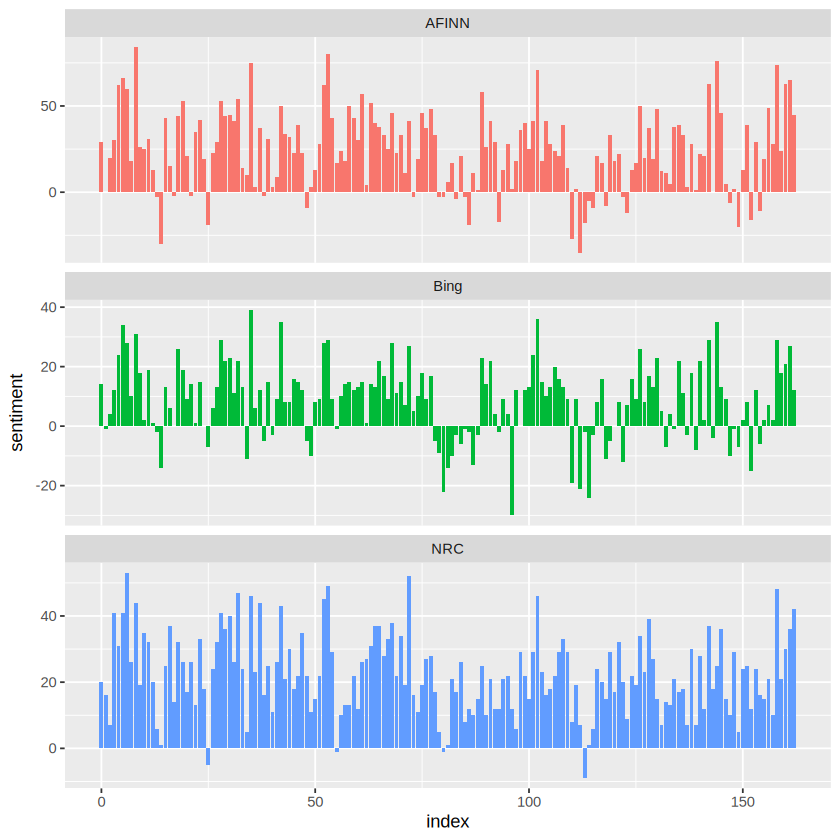

In [23]:
# ========================================================
# Step 3: Visualize on the net sentiment
# ========================================================

book_three_sentiment %>%
    ggplot(aes(index, sentiment, fill = method)) +
              geom_col(show.legend = FALSE) +
              facet_wrap(~method, ncol = 1, scales = "free_y")

Joining with `by = join_by(word)`
Warning message in inner_join(., bing):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 435434 of `x` matches multiple rows in `y`.
ℹ Row 5051 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


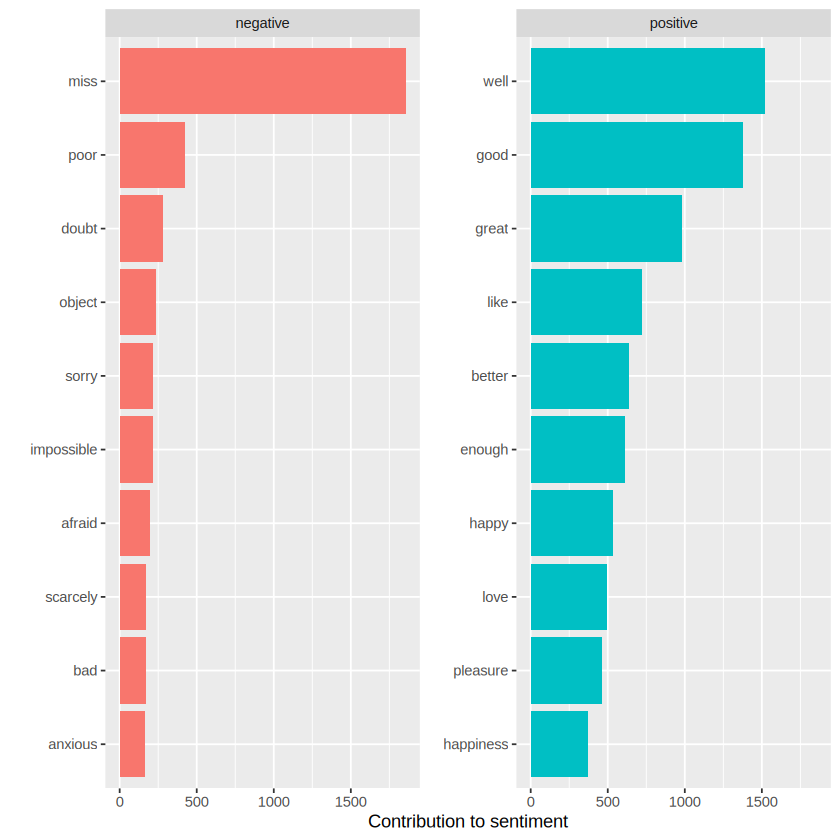

In [24]:
# ========================================================
# Step 4: Bing - Histogram Plot: Most common positive and negative words
# ========================================================

bing_word_counts <- tidy_books %>%
                      inner_join(bing) %>%
                      count(word, sentiment, sort = TRUE) %>%
                      ungroup()

bing_word_counts %>%
    group_by(sentiment) %>%
    slice_max(n, n = 10) %>%
    ungroup() %>%
    mutate(word = reorder(word, n)) %>%
    ggplot(aes(n, word, fill = sentiment)) +
        geom_col(show.legend = FALSE) +
        facet_wrap(~sentiment, scales = "free_y") +
        labs(x = "Contribution to sentiment",
              y = NULL)

In [25]:
# ========================================================
# Step 5: Customize stop words
# ========================================================

custom_stop_words <- bind_rows(tibble(word = c("miss"),lexicon = c("custom")),
                               stop_words
                              )

custom_stop_words

word,lexicon
<chr>,<chr>
miss,custom
a,SMART
a's,SMART
able,SMART
about,SMART
above,SMART
according,SMART
accordingly,SMART
across,SMART


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Joining with `by = join_by(word)`


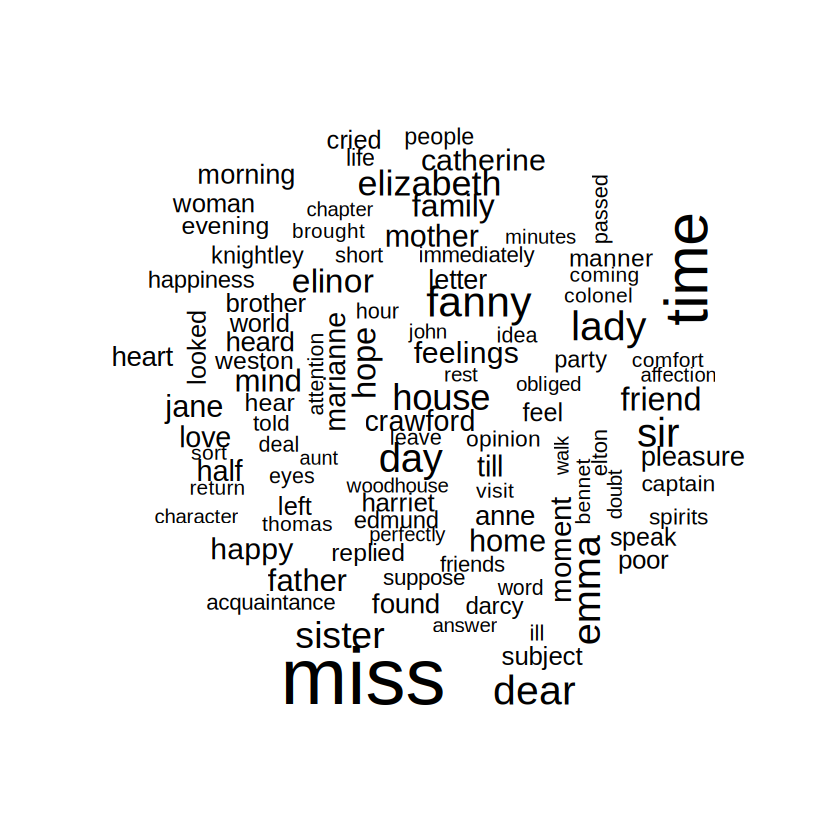

In [26]:
# ========================================================
# Step 6: World clouds
# ========================================================

install.packages("wordcloud")
library(wordcloud)

tidy_books %>%
  anti_join(stop_words) %>%
  count(word) %>%
  with(wordcloud(word, n, max.words = 100))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘plyr’



Attaching package: ‘reshape2’


The following object is masked from ‘package:tidyr’:

    smiths


Joining with `by = join_by(word)`
Warning message in inner_join(., get_sentiments("bing")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 435434 of `x` matches multiple rows in `y`.
ℹ Row 5051 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


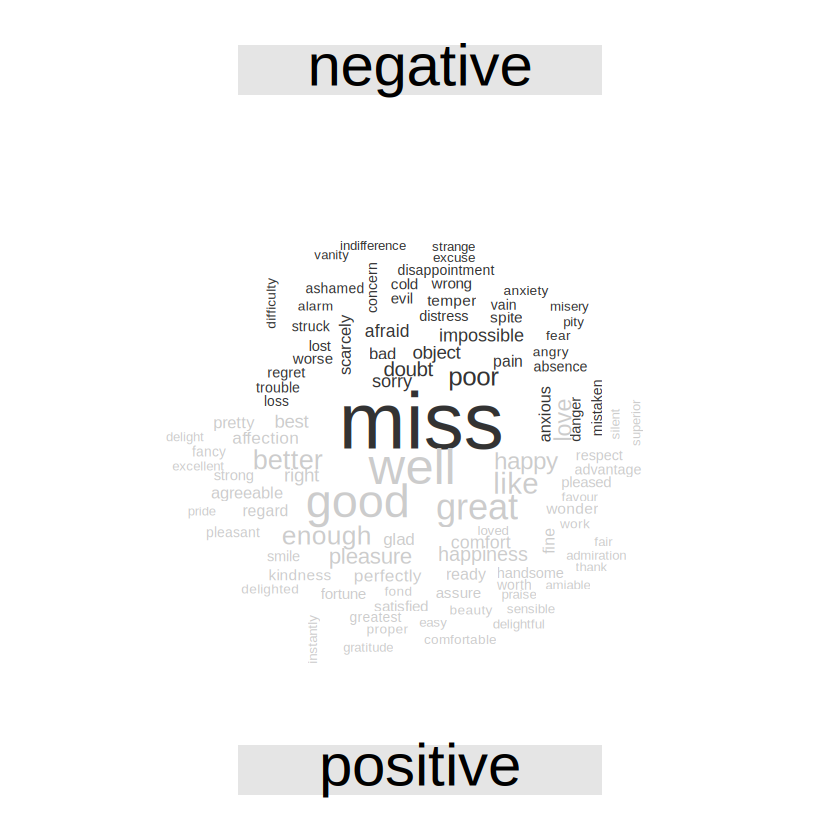

In [27]:
# ========================================================
# Step 7: Comparison World clouds
# ========================================================

install.packages("reshape2")
library(reshape2)

tidy_books %>%
  inner_join(get_sentiments("bing")) %>%
  count(word, sentiment, sort = TRUE) %>%
  acast(word ~ sentiment, value.var = "n", fill = 0) %>%
  comparison.cloud(colors = c("gray20", "gray80"),
                   max.words = 100)